# Data Analysis

Statistical analyses for the paper.

**Inputs required** (all produced by earlier notebooks / scripts):
- `data/filtered_observations.csv` — from `01_video_processing.ipynb`
- `data/derived/model_input.csv` — from `02_prepare_model_input.ipynb`
- `data/derived/response_videos.csv` — from `02_prepare_model_input.ipynb`
- `data/all_observations.csv` — from `01_video_processing.ipynb`
- `data/derived/all_positions.csv` — from `01_video_processing.ipynb`
- `data/derived/all_distances.csv` — from `01_video_processing.ipynb`
- `outputs/model_fitting/model_comparisons.csv` — from `scripts/03_model_fitting.R`

### Import libraries

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from scipy.spatial.distance import cdist
from sklearn.mixture import GaussianMixture
import pickle
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
import seaborn as sns

### Load dataset & Set parameters

In [2]:
from pathlib import Path

path = Path('..')

model_input    = pd.read_csv(path / 'data' / 'derived' / 'model_input.csv')
ResponseVideos = pd.read_csv(path / 'data' / 'derived' / 'response_videos.csv')
Summaries      = pd.read_csv(path / 'data' / 'all_observations.csv')
Positions      = pd.read_csv(path / 'data' / 'derived' / 'all_positions.csv')
Distances      = pd.read_csv(path / 'data' / 'derived' / 'all_distances.csv')

# First responders — filtered from full dataset for speed analysis
FR_fish = Summaries[Summaries['Response_Category'] == 'FR'].copy()


In [3]:
# Filter Summaries to only Response Videos
Summaries = Summaries[Summaries['Response_Video'] == 'Yes']
print(len(Summaries))

1304


In [4]:
OUT_DIR = Path('..') / 'outputs' / 'data_analysis'
OUT_DIR.mkdir(parents=True, exist_ok=True)


## Answers to questions

### 0. What is the fitted decay rate to the SRNL speed?

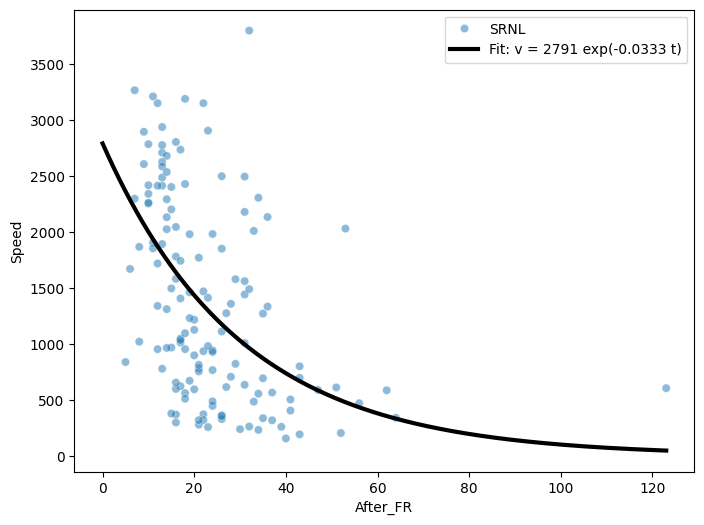

In [ ]:
# ---- Your existing scatter ----
fig, ax = plt.subplots(figsize=(8, 6))

Summaries_SRNL = Summaries[
    Summaries['Response_Category'].isin(['SRNL'])
]

sns.scatterplot(
    data=Summaries_SRNL,
    x='After_FR',
    y='Speed',
    hue='Response_Category',
    ax=ax,
    alpha=0.5
)

# ---- Add exponential decay curve ----

# Use the lambda and a you fitted
a = a_hat
lam = lambda_hat

# Generate smooth time axis
t_smooth = np.linspace(0, Summaries_SRNL['After_FR'].max(), 300)

# Compute fitted curve
v_fit = a * np.exp(-lam * t_smooth)

# Plot
ax.plot(
    t_smooth,
    v_fit,
    color='black',
    linewidth=3,
    label=f'Fit: v = {a:.0f} exp(-{lam:.4f} t)'
)

ax.legend()

plt.show()


In [29]:
FR_mean = Summaries[
    Summaries["Response_Category"] == "FR"
]["Speed"].mean()

FR_median = Summaries[
    Summaries["Response_Category"] == "FR"
]["Speed"].median()

V_FR = FR_mean  # or FR_median

print(V_FR)

1560.5254336933554


In [46]:
from scipy.optimize import curve_fit
import numpy as np

def exp_decay(t, a, lam):
    return a * np.exp(-lam * t)

df_fit = Summaries[
    (Summaries["Response_Category"].isin(['SRNL'])) &
    (Summaries["After_FR"] > 0)
].copy()

t = df_fit["After_FR"].values
v = df_fit["Speed"].values

popt, pcov = curve_fit(
    exp_decay,
    t,
    v,
    p0=(2.0, 0.03)  # initial guesses
)

a_hat, lambda_hat= popt

print("Estimated lambda:", lambda_hat)
print("a:", a_hat)


Estimated lambda: 0.03326628003223066
a: 2790.5081499608996


In [27]:
df_fit = Summaries[
    (Summaries["Response_Category"].isin(['SRL', 'SRNL'])) &
    (Summaries["After_FR"] > 0) &
    (Summaries["Speed"] > 0)
].copy()

df_fit["log_ratio"] = np.log(df_fit["Speed"] / V_FR)

X = df_fit[["After_FR"]]   # NO constant
y = df_fit["log_ratio"]

model = sm.OLS(y, X).fit()

lambda_hat = -model.params["After_FR"]

print("Estimated lambda:", lambda_hat)
print(model.summary())

Estimated lambda: 0.018258322062953098
                                 OLS Regression Results                                
Dep. Variable:              log_ratio   R-squared (uncentered):                   0.336
Model:                            OLS   Adj. R-squared (uncentered):              0.333
Method:                 Least Squares   F-statistic:                              143.0
Date:                Tue, 17 Feb 2026   Prob (F-statistic):                    5.98e-27
Time:                        22:03:12   Log-Likelihood:                         -295.17
No. Observations:                 284   AIC:                                      592.3
Df Residuals:                     283   BIC:                                      596.0
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
--

### 1. Is there an effect of deployment (trial) on cascade size (fraction responders)?

In [6]:
model1 = smf.glm(formula='Nr_Responders + Nr_NonResponders ~ C(Dep_ID)', data=ResponseVideos, family=sm.families.Binomial()).fit(cov_type='HC3')
model0 = smf.glm(formula='Nr_Responders + Nr_NonResponders ~ 1', data=ResponseVideos, family=sm.families.Binomial()).fit(cov_type='HC3')


lr = 2 * (model1.llf - model0.llf)
df_diff = model1.df_model - model0.df_model
p = chi2.sf(lr, df_diff)

print(lr, df_diff, p)


227.16946023789762 11 1.6529370747522114e-42


### 2. Is the fraction of unknown responders related to group size?

In [7]:
ResponseVideos['Nr_Known'] = ResponseVideos['Nr_FR'] + ResponseVideos['Nr_SRL'] + ResponseVideos['Nr_SRNL'] + ResponseVideos['Nr_NRL_r'] + ResponseVideos['Nr_NRNL_r']
ResponseVideos['Nr_Unknown'] = ResponseVideos['Nr_SRUD'] + ResponseVideos['Nr_NRUD'] + ResponseVideos['Nr_SRTC'] + ResponseVideos['Nr_NRTC']

model2 = smf.glm(formula="Nr_Unknown + Nr_Known ~ Group_Size", data=ResponseVideos, family=sm.families.Binomial()).fit(cov_type='cluster', cov_kwds={'groups': ResponseVideos['Dep_ID']})
print(model2.summary())

                     Generalized Linear Model Regression Results                      
Dep. Variable:     ['Nr_Unknown', 'Nr_Known']   No. Observations:                   74
Model:                                    GLM   Df Residuals:                       72
Model Family:                        Binomial   Df Model:                            1
Link Function:                          Logit   Scale:                          1.0000
Method:                                  IRLS   Log-Likelihood:                -120.31
Date:                        Tue, 03 Feb 2026   Deviance:                       119.60
Time:                                13:07:57   Pearson chi2:                     104.
No. Iterations:                             5   Pseudo R-squ. (CS):            0.05666
Covariance Type:                      cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------

### 3. What is the effect of stimulus speed on cascade size (fraction responders)?

In [8]:
model3 = smf.glm(formula='Nr_Responders + Nr_NonResponders ~ Loom_Speed', data=ResponseVideos, family=sm.families.Binomial()).fit(cov_type='cluster', cov_kwds={'groups': ResponseVideos['Dep_ID']})
print(model3.summary())

                           Generalized Linear Model Regression Results                           
Dep. Variable:     ['Nr_Responders', 'Nr_NonResponders']   No. Observations:                   74
Model:                                               GLM   Df Residuals:                       72
Model Family:                                   Binomial   Df Model:                            1
Link Function:                                     Logit   Scale:                          1.0000
Method:                                             IRLS   Log-Likelihood:                -434.48
Date:                                   Tue, 03 Feb 2026   Deviance:                       704.51
Time:                                           13:07:57   Pearson chi2:                     631.
No. Iterations:                                        4   Pseudo R-squ. (CS):            0.06453
Covariance Type:                                 cluster                                         
                 coe

### 4. What is the effect of the fraction of fish seeing the stimulus on cascade size (fraction responders)?

In [9]:
model4 = smf.glm(formula='Nr_Responders + Nr_NonResponders ~ Fraction_Seeing', data=ResponseVideos, family=sm.families.Binomial()).fit(cov_type='cluster', cov_kwds={'groups': ResponseVideos['Dep_ID']})
print(model4.summary())

                           Generalized Linear Model Regression Results                           
Dep. Variable:     ['Nr_Responders', 'Nr_NonResponders']   No. Observations:                   74
Model:                                               GLM   Df Residuals:                       72
Model Family:                                   Binomial   Df Model:                            1
Link Function:                                     Logit   Scale:                          1.0000
Method:                                             IRLS   Log-Likelihood:                -425.38
Date:                                   Tue, 03 Feb 2026   Deviance:                       686.31
Time:                                           13:07:57   Pearson chi2:                     625.
No. Iterations:                                        4   Pseudo R-squ. (CS):             0.2685
Covariance Type:                                 cluster                                         
                    

### 5. What is the effect of group size on the overall cascade size (fraction responders)?

In [10]:
model5 = smf.glm(formula='Nr_Responders + Nr_NonResponders ~ Group_Size', data=ResponseVideos, family=sm.families.Binomial()).fit(cov_type='cluster', cov_kwds={'groups': ResponseVideos['Dep_ID']})
print(model5.summary())
print(model5.pvalues)

                           Generalized Linear Model Regression Results                           
Dep. Variable:     ['Nr_Responders', 'Nr_NonResponders']   No. Observations:                   74
Model:                                               GLM   Df Residuals:                       72
Model Family:                                   Binomial   Df Model:                            1
Link Function:                                     Logit   Scale:                          1.0000
Method:                                             IRLS   Log-Likelihood:                -387.60
Date:                                   Tue, 03 Feb 2026   Deviance:                       610.74
Time:                                           13:07:57   Pearson chi2:                     562.
No. Iterations:                                        4   Pseudo R-squ. (CS):             0.7365
Covariance Type:                                 cluster                                         
                 coe

### 6. What is the effect of group size on the cascade size of social-only responders?

In [11]:
model6 = smf.glm(formula='Nr_SRNL + Nr_NRNL_r ~ Group_Size', data=ResponseVideos, family=sm.families.Binomial()).fit(cov_type='cluster', cov_kwds={'groups': ResponseVideos['Dep_ID']})
print(model6.summary())

                    Generalized Linear Model Regression Results                     
Dep. Variable:     ['Nr_SRNL', 'Nr_NRNL_r']   No. Observations:                   74
Model:                                  GLM   Df Residuals:                       72
Model Family:                      Binomial   Df Model:                            1
Link Function:                        Logit   Scale:                          1.0000
Method:                                IRLS   Log-Likelihood:                -233.91
Date:                      Tue, 03 Feb 2026   Deviance:                       418.78
Time:                              13:07:57   Pearson chi2:                     381.
No. Iterations:                           4   Pseudo R-squ. (CS):             0.1164
Covariance Type:                    cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------

#### 6a. What is the effect of group size of the cascade size of social-only responders when UD and TC fish are included as NL fish?


In [12]:
df_6a = ResponseVideos.copy()
df_6a['Nr_SRNL_Inclusive'] = df_6a['Nr_SRNL'] + df_6a['Nr_SRUD'] + df_6a['Nr_SRTC']
df_6a['Nr_NRNL_Inclusive'] = df_6a['Nr_NRNL_r'] + df_6a['Nr_NRUD'] + df_6a['Nr_NRTC']

model6a = smf.glm(formula='Nr_SRNL_Inclusive + Nr_NRNL_Inclusive ~ Group_Size', data=df_6a, family=sm.families.Binomial()).fit(cov_type='cluster', cov_kwds={'groups': df_6a['Dep_ID']})
print(model6a.summary())

                             Generalized Linear Model Regression Results                              
Dep. Variable:     ['Nr_SRNL_Inclusive', 'Nr_NRNL_Inclusive']   No. Observations:                   74
Model:                                                    GLM   Df Residuals:                       72
Model Family:                                        Binomial   Df Model:                            1
Link Function:                                          Logit   Scale:                          1.0000
Method:                                                  IRLS   Log-Likelihood:                -268.12
Date:                                        Tue, 03 Feb 2026   Deviance:                       477.35
Time:                                                13:07:57   Pearson chi2:                     426.
No. Iterations:                                             4   Pseudo R-squ. (CS):             0.2364
Covariance Type:                                      cluster            

### 7. What is the effect of group size on the cascade size of visual + social responders?

In [13]:
df_7 = ResponseVideos.copy()
df_7 = df_7[(df_7['Nr_SRL'] + df_7['Nr_NRL_r']) > 0]

model7 = smf.glm(formula='Nr_SRL + Nr_NRL_r ~ Group_Size', data=df_7, family=sm.families.Binomial()).fit(cov_type='cluster', cov_kwds={'groups': df_7['Dep_ID']})
print(model7.summary())

                   Generalized Linear Model Regression Results                    
Dep. Variable:     ['Nr_SRL', 'Nr_NRL_r']   No. Observations:                   72
Model:                                GLM   Df Residuals:                       70
Model Family:                    Binomial   Df Model:                            1
Link Function:                      Logit   Scale:                          1.0000
Method:                              IRLS   Log-Likelihood:                -185.94
Date:                    Tue, 03 Feb 2026   Deviance:                       311.50
Time:                            13:07:57   Pearson chi2:                     256.
No. Iterations:                         4   Pseudo R-squ. (CS):             0.4504
Covariance Type:                  cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   

### 8. Is there an interaction effect between group size and stimulus speed on cascade size (fraction responders)?

In [14]:
model8 = smf.glm(formula='Nr_Responders + Nr_NonResponders ~ Loom_Speed * Group_Size', data=ResponseVideos, family=sm.families.Binomial()).fit(cov_type='cluster', cov_kwds={'groups': ResponseVideos['Dep_ID']})
print(model8.summary())

                           Generalized Linear Model Regression Results                           
Dep. Variable:     ['Nr_Responders', 'Nr_NonResponders']   No. Observations:                   74
Model:                                               GLM   Df Residuals:                       70
Model Family:                                   Binomial   Df Model:                            3
Link Function:                                     Logit   Scale:                          1.0000
Method:                                             IRLS   Log-Likelihood:                -378.66
Date:                                   Tue, 03 Feb 2026   Deviance:                       592.88
Time:                                           13:07:57   Pearson chi2:                     582.
No. Iterations:                                        5   Pseudo R-squ. (CS):             0.7930
Covariance Type:                                 cluster                                         
                    

### 9. Is there an interaction effect between fraction of fish seeing the stimulus and stimulus speed on cascade size (fraction responders)?

In [15]:
model9 = smf.glm(formula='Nr_Responders + Nr_NonResponders ~ Loom_Speed * Fraction_Seeing', data=ResponseVideos, family=sm.families.Binomial()).fit(cov_type='cluster', cov_kwds={'groups': ResponseVideos['Dep_ID']})
print(model9.summary())

                           Generalized Linear Model Regression Results                           
Dep. Variable:     ['Nr_Responders', 'Nr_NonResponders']   No. Observations:                   74
Model:                                               GLM   Df Residuals:                       70
Model Family:                                   Binomial   Df Model:                            3
Link Function:                                     Logit   Scale:                          1.0000
Method:                                             IRLS   Log-Likelihood:                -405.82
Date:                                   Tue, 03 Feb 2026   Deviance:                       647.18
Time:                                           13:07:57   Pearson chi2:                     682.
No. Iterations:                                        4   Pseudo R-squ. (CS):             0.5689
Covariance Type:                                 cluster                                         
                    

### 10. What is the effect of initiators response speeds on cascade size (fraction responders)?

In [16]:
FR_MeanSpeeds = []
FR_MedianSpeeds = []
FR_SumSpeeds = []
FR_MaxSpeeds = []

for index, row in ResponseVideos.iterrows():
    Summary = Summaries[Summaries['Video_ID'] == row['Video_ID']]
    FRs = Summary[Summary['Response_Category'] == 'FR']
    FR_MeanSpeeds.append(FRs['Speed'].mean())
    FR_MedianSpeeds.append(FRs['Speed'].median())
    FR_SumSpeeds.append(FRs['Speed'].sum())
    FR_MaxSpeeds.append(FRs['Speed'].max())

ResponseVideos['FR_MeanSpeed'] = FR_MeanSpeeds
ResponseVideos['FR_MedianSpeed'] = FR_MedianSpeeds
ResponseVideos['FR_SumSpeed'] = FR_SumSpeeds
ResponseVideos['FR_MaxSpeed'] = FR_MaxSpeeds

ResponseVideos.to_csv('../Information/ResponseVideos.csv', index=False)

In [17]:
ResponseVideos[['FR_MeanSpeed',
                'FR_MedianSpeed',
                'FR_SumSpeed',
                'FR_MaxSpeed']].describe()


,FR_MeanSpeed,FR_MedianSpeed,FR_SumSpeed,FR_MaxSpeed
count,74.000000,74.000000,74.000000,74.000000
mean,1443.270690,1447.286656,2235.347243,1565.131937
std,661.556381,687.609678,2090.839700,796.747881
min,395.789080,395.789080,395.789080,395.789080
25%,910.930477,910.930477,965.819578,946.743000
50%,1340.269308,1340.269308,1492.074983,1350.627103
75%,1850.782491,1801.985644,2623.115430,1978.756167
max,3061.784265,3532.827044,11997.492607,3983.545641


In [18]:
ResponseVideos['FR_MeanSpeed_z'] = (
    ResponseVideos['FR_MeanSpeed'] -
    ResponseVideos['FR_MeanSpeed'].mean()
) / ResponseVideos['FR_MeanSpeed'].std()

ResponseVideos['FR_MedianSpeed_z'] = (
    ResponseVideos['FR_MedianSpeed'] -
    ResponseVideos['FR_MedianSpeed'].mean()
) / ResponseVideos['FR_MedianSpeed'].std()

ResponseVideos['FR_SumSpeed_z'] = (
    ResponseVideos['FR_SumSpeed'] -
    ResponseVideos['FR_SumSpeed'].mean()
) / ResponseVideos['FR_SumSpeed'].std()

ResponseVideos['FR_MaxSpeed_z'] = (
    ResponseVideos['FR_MaxSpeed'] -
    ResponseVideos['FR_MaxSpeed'].mean()
) / ResponseVideos['FR_MaxSpeed'].std()

ResponseVideos.to_csv('../Information/ResponseVideos.csv', index=False)

In [19]:
ResponseVideos[['FR_MeanSpeed_z',
                'FR_MedianSpeed_z',
                'FR_SumSpeed_z',
                'FR_MaxSpeed_z']].describe()


,FR_MeanSpeed_z,FR_MedianSpeed_z,FR_SumSpeed_z,FR_MaxSpeed_z
count,7.400000e+01,7.400000e+01,7.400000e+01,7.400000e+01
mean,1.665335e-16,-1.350271e-16,1.125226e-18,8.626733e-17
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-1.583360e+00,-1.529207e+00,-8.798179e-01,-1.467645e+00
25%,-8.046785e-01,-7.800300e-01,-6.071856e-01,-7.761413e-01
50%,-1.556955e-01,-1.556368e-01,-3.554898e-01,-2.692255e-01
75%,6.159895e-01,5.158435e-01,1.854605e-01,5.191407e-01
max,2.446524e+00,3.033029e+00,4.669007e+00,3.035356e+00


#### 10.1. FR mean speed

In [20]:
model101 = smf.glm(formula='Nr_Responders + Nr_NonResponders ~ FR_MeanSpeed_z', data=ResponseVideos, family=sm.families.Binomial()).fit(cov_type='cluster', cov_kwds={'groups': ResponseVideos['Dep_ID']})
print(model101.summary())
print(model101.pvalues)

                           Generalized Linear Model Regression Results                           
Dep. Variable:     ['Nr_Responders', 'Nr_NonResponders']   No. Observations:                   74
Model:                                               GLM   Df Residuals:                       72
Model Family:                                   Binomial   Df Model:                            1
Link Function:                                     Logit   Scale:                          1.0000
Method:                                             IRLS   Log-Likelihood:                -337.96
Date:                                   Tue, 03 Feb 2026   Deviance:                       511.47
Time:                                           13:07:57   Pearson chi2:                     493.
No. Iterations:                                        4   Pseudo R-squ. (CS):             0.9311
Covariance Type:                                 cluster                                         
                    

#### 10.2. FR median speed

In [21]:
model102 = smf.glm(formula='Nr_Responders + Nr_NonResponders ~ FR_MedianSpeed_z', data=ResponseVideos, family=sm.families.Binomial()).fit(cov_type='cluster', cov_kwds={'groups': ResponseVideos['Dep_ID']})
print(model102.summary())
print(model102.pvalues)

                           Generalized Linear Model Regression Results                           
Dep. Variable:     ['Nr_Responders', 'Nr_NonResponders']   No. Observations:                   74
Model:                                               GLM   Df Residuals:                       72
Model Family:                                   Binomial   Df Model:                            1
Link Function:                                     Logit   Scale:                          1.0000
Method:                                             IRLS   Log-Likelihood:                -339.64
Date:                                   Tue, 03 Feb 2026   Deviance:                       514.83
Time:                                           13:07:57   Pearson chi2:                     496.
No. Iterations:                                        4   Pseudo R-squ. (CS):             0.9279
Covariance Type:                                 cluster                                         
                    

#### 10.3. FR combined speed

In [22]:
model103 = smf.glm(formula='Nr_Responders + Nr_NonResponders ~ FR_SumSpeed_z', data=ResponseVideos, family=sm.families.Binomial()).fit(cov_type='cluster', cov_kwds={'groups': ResponseVideos['Dep_ID']})
print(model103.summary())
print(model103.pvalues)

                           Generalized Linear Model Regression Results                           
Dep. Variable:     ['Nr_Responders', 'Nr_NonResponders']   No. Observations:                   74
Model:                                               GLM   Df Residuals:                       72
Model Family:                                   Binomial   Df Model:                            1
Link Function:                                     Logit   Scale:                          1.0000
Method:                                             IRLS   Log-Likelihood:                -340.17
Date:                                   Tue, 03 Feb 2026   Deviance:                       515.89
Time:                                           13:07:57   Pearson chi2:                     525.
No. Iterations:                                        5   Pseudo R-squ. (CS):             0.9269
Covariance Type:                                 cluster                                         
                    

#### 10.4 FR maximum speed

In [23]:
model104 = smf.glm(formula='Nr_Responders + Nr_NonResponders ~ FR_MaxSpeed_z', data=ResponseVideos, family=sm.families.Binomial()).fit(cov_type='cluster', cov_kwds={'groups': ResponseVideos['Dep_ID']})
print(model104.summary())
print(model104.pvalues)

                           Generalized Linear Model Regression Results                           
Dep. Variable:     ['Nr_Responders', 'Nr_NonResponders']   No. Observations:                   74
Model:                                               GLM   Df Residuals:                       72
Model Family:                                   Binomial   Df Model:                            1
Link Function:                                     Logit   Scale:                          1.0000
Method:                                             IRLS   Log-Likelihood:                -317.40
Date:                                   Tue, 03 Feb 2026   Deviance:                       470.34
Time:                                           13:07:57   Pearson chi2:                     469.
No. Iterations:                                        5   Pseudo R-squ. (CS):             0.9605
Covariance Type:                                 cluster                                         
                    

### 12. Is there an interaction effect between number of initial responders and group size on the cascade size (fraction responders)?

In [24]:
model12 = smf.glm(formula='Nr_Responders + Nr_NonResponders ~ Nr_FR * Group_Size', data=ResponseVideos, family=sm.families.Binomial()).fit(cov_type='cluster', cov_kwds={'groups': ResponseVideos['Dep_ID']})
print(model12.summary())

                           Generalized Linear Model Regression Results                           
Dep. Variable:     ['Nr_Responders', 'Nr_NonResponders']   No. Observations:                   74
Model:                                               GLM   Df Residuals:                       70
Model Family:                                   Binomial   Df Model:                            3
Link Function:                                     Logit   Scale:                          1.0000
Method:                                             IRLS   Log-Likelihood:                -335.73
Date:                                   Tue, 03 Feb 2026   Deviance:                       507.01
Time:                                           13:07:57   Pearson chi2:                     502.
No. Iterations:                                        5   Pseudo R-squ. (CS):             0.9351
Covariance Type:                                 cluster                                         
                    

### 13. How many additional individuals are recruited by the initiators?

In [25]:
ResponseVideos['Nr_NonFR_Responders'] = ResponseVideos['Nr_Responders'] - ResponseVideos['Nr_FR']

model13 = smf.glm(formula='Nr_NonFR_Responders + Nr_NonResponders ~ Nr_FR * Group_Size', data=ResponseVideos, family=sm.families.Binomial()).fit(cov_type='cluster', cov_kwds={'groups': ResponseVideos['Dep_ID']})
print(model13.summary())

                              Generalized Linear Model Regression Results                              
Dep. Variable:     ['Nr_NonFR_Responders', 'Nr_NonResponders']   No. Observations:                   74
Model:                                                     GLM   Df Residuals:                       70
Model Family:                                         Binomial   Df Model:                            3
Link Function:                                           Logit   Scale:                          1.0000
Method:                                                   IRLS   Log-Likelihood:                -365.63
Date:                                         Tue, 03 Feb 2026   Deviance:                       625.91
Time:                                                 13:07:57   Pearson chi2:                     592.
No. Iterations:                                              5   Pseudo R-squ. (CS):             0.8399
Covariance Type:                                       cluster  

### 14. Is there an interaction effect between number of initial responders and group size on the fraction of social-only responders?

In [26]:
model14 = smf.glm(formula='Nr_SRNL + Nr_NRNL_r ~ Nr_FR * Group_Size', data=ResponseVideos, family=sm.families.Binomial()).fit(cov_type='cluster', cov_kwds={'groups': ResponseVideos['Dep_ID']})
print(model14.summary())

                    Generalized Linear Model Regression Results                     
Dep. Variable:     ['Nr_SRNL', 'Nr_NRNL_r']   No. Observations:                   74
Model:                                  GLM   Df Residuals:                       70
Model Family:                      Binomial   Df Model:                            3
Link Function:                        Logit   Scale:                          1.0000
Method:                                IRLS   Log-Likelihood:                -222.58
Date:                      Tue, 03 Feb 2026   Deviance:                       396.12
Time:                              13:07:57   Pearson chi2:                     379.
No. Iterations:                           4   Pseudo R-squ. (CS):             0.3494
Covariance Type:                    cluster                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

### 15. What is the difference in spacing between smaller and larger groups?

In [27]:
Summaries_Known = Summaries[Summaries['Response_Category'].isin(['FR', 'SRL', 'NRL', 'SRNL', 'NRNL_r'])].copy()

In [28]:
MedianNNDs = []

for index, row in ResponseVideos.iterrows():
    VideoDistances = Distances[Distances['Video_ID'] == row['Video_ID']].copy()
    VideoDistances = VideoDistances.drop(columns=['Dep_ID', 'Video_ID', 'Fish_ID', 'Size (in mm)'])
    # Set 0 to NaN to avoid self-distance
    VideoDistances = VideoDistances.replace(0, np.nan)
    # Take minimum distance for each fish (row)
    NND = VideoDistances.min(axis=1)
    MedianNNDs.append(NND.median())

ResponseVideos['Median_NND'] = MedianNNDs
ResponseVideos.to_csv('../Information/ResponseVideos.csv', index=False)

In [29]:
MedianNPs = []

for index, row in ResponseVideos.iterrows():
    VideoDistances = Summaries_Known[Summaries_Known['Video_ID'] == row['Video_ID']].copy()
    VideoDistances['Neighbour_Proximity'] = VideoDistances['Neighbour_Proximity'].replace(0, np.nan)
    MedianNPs.append(VideoDistances['Neighbour_Proximity'].median())

ResponseVideos['Median_NP'] = MedianNPs


### Fish-level: Local Crowding ~ GSz

In [32]:
model15c = smf.ols(formula='Neighbour_Proximity ~ Group_Size', data=Summaries_Known).fit(cov_type='cluster', cov_kwds={'groups': Summaries_Known['Video_ID']})
print(model15c.summary())

                            OLS Regression Results                            
Dep. Variable:          Local_Density   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     11.81
Date:                Tue, 03 Feb 2026   Prob (F-statistic):           0.000974
Time:                        13:07:57   Log-Likelihood:                -5534.2
No. Observations:                 834   AIC:                         1.107e+04
Df Residuals:                     832   BIC:                         1.108e+04
Df Model:                           1                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     29.0266     12.535      2.316      0.0

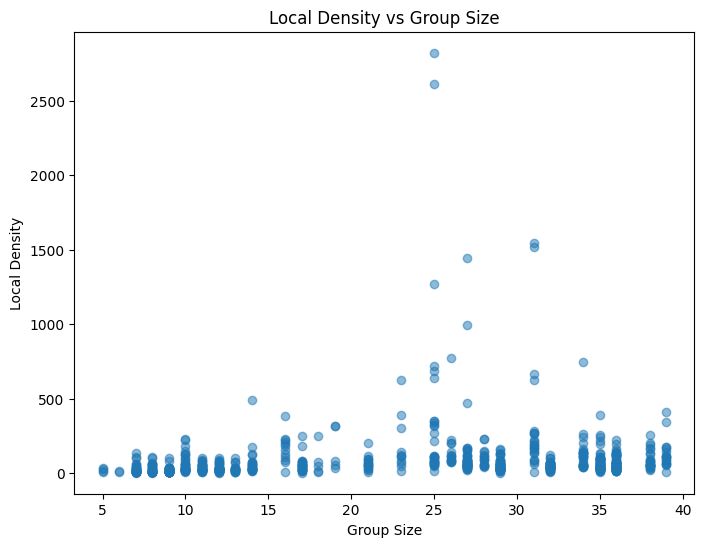

In [33]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(Summaries_Known['Group_Size'], Summaries_Known['Neighbour_Proximity'], alpha=0.5)
ax.set_xlabel('Group Size')
ax.set_ylabel('Local Density')
ax.set_title('Local Density vs Group Size')
plt.show()

In [34]:
NNDs = []

for _, r in Summaries_Known.iterrows():
    # Select the ONE row for this fish in this video
    fish_row = Distances.loc[
        (Distances["Video_ID"] == r["Video_ID"]) &
        (Distances["Fish_ID"]  == r["Fish_ID"])
    ]

    if fish_row.empty:
        NNDs.append(np.nan)
        continue

    fish_row = fish_row.iloc[0]

    # Keep only distance columns (everything except metadata)
    dist_vals = fish_row.drop(
        labels=["Dep_ID", "Video_ID", "Fish_ID", "Size (in mm)"],
        errors="ignore"
    )

    # Force numeric, ignore non-distance junk safely
    dist_vals = pd.to_numeric(dist_vals, errors="coerce")

    # Remove self-distance zeros (and any other zeros you used as placeholders)
    dist_vals = dist_vals.replace(0, np.nan)

    # Fish-specific NND = min distance to any other fish
    NNDs.append(dist_vals.min())

Summaries_Known["NND"] = NNDs
Summaries_Known.to_csv('../Information/ResponseVideo-Known-Summaries.csv', index=False)

In [35]:
model15d = smf.ols(formula='NND ~ Group_Size', data=Summaries_Known).fit(cov_type='cluster', cov_kwds={'groups': Summaries_Known['Video_ID']})
print(model15d.summary())

                            OLS Regression Results                            
Dep. Variable:                    NND   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     11.21
Date:                Tue, 03 Feb 2026   Prob (F-statistic):            0.00129
Time:                        13:07:58   Log-Likelihood:                -5754.9
No. Observations:                 834   AIC:                         1.151e+04
Df Residuals:                     832   BIC:                         1.152e+04
Df Model:                           1                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    423.6302     25.705     16.480      0.0

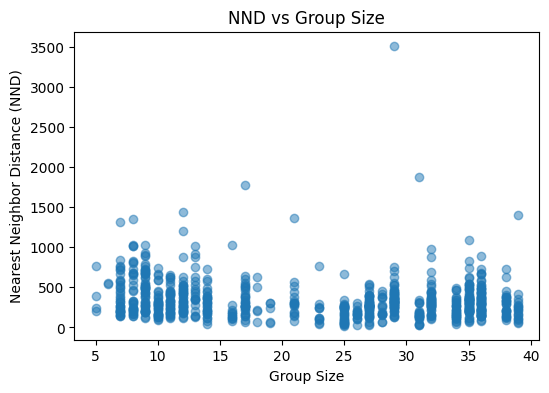

In [36]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(Summaries_Known['Group_Size'], Summaries_Known['NND'], alpha=0.5)
ax.set_xlabel('Group Size')
ax.set_ylabel('Nearest Neighbor Distance (NND)')
ax.set_title('NND vs Group Size')
plt.show()

In [37]:
BL_med_global = Summaries_Known['Size'].median() + Summaries_Known['Size'].median() * 0.3 # Tail is a 3rd of their body length
print('Body length median global:', BL_med_global)
c = 2
R_mm = c * BL_med_global
print('R in mm:', R_mm)

Body length median global: 64.56999090443722
R in mm: 129.13998180887444


In [ ]:
counts = []
meta_cols = {"Dep_ID", "Video_ID", "Fish_ID", "Size"}

for _, r in Summaries_Known.iterrows():
    fish_row = Distances.loc[
        (Distances["Video_ID"] == r["Video_ID"]) &
        (Distances["Fish_ID"]  == r["Fish_ID"])
    ]

    if fish_row.empty:
        counts.append(np.nan)
        continue

    fish_row = fish_row.iloc[0]
    dist_vals = fish_row.drop(
        labels=[c for c in meta_cols if c in fish_row.index],
        errors="ignore"
    )

    dist_vals = pd.to_numeric(dist_vals, errors="coerce")
    dist_vals = dist_vals.replace(0, np.nan)

    counts.append((dist_vals <= R_mm).sum())

Summaries_Known["Count_in_2BL"] = counts
Summaries_Known.to_csv('../Information/ResponseVideo-Known-Summaries.csv', index=False)


In [39]:
model15e = smf.ols(formula='Count_in_2BL ~ Group_Size', data=Summaries_Known).fit(cov_type='cluster', cov_kwds={'groups': Summaries_Known['Video_ID']})
print(model15e.summary())

                            OLS Regression Results                            
Dep. Variable:           Count_in_2BL   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     3.981
Date:                Tue, 03 Feb 2026   Prob (F-statistic):             0.0498
Time:                        13:07:58   Log-Likelihood:                -579.24
No. Observations:                 834   AIC:                             1162.
Df Residuals:                     832   BIC:                             1172.
Df Model:                           1                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.0204      0.042     24.384      0.0

In [40]:
import numpy as np
import pandas as pd

mean_dists = []

meta_cols = {"Dep_ID", "Video_ID", "Fish_ID", "Size"}

for _, r in Summaries_Known.iterrows():

    fish_row = Distances.loc[
        (Distances["Video_ID"] == r["Video_ID"]) &
        (Distances["Fish_ID"]  == r["Fish_ID"])
    ]

    if fish_row.empty:
        mean_dists.append(np.nan)
        continue

    fish_row = fish_row.iloc[0]

    dist_vals = fish_row.drop(
        labels=[c for c in meta_cols if c in fish_row.index],
        errors="ignore"
    )

    dist_vals = pd.to_numeric(dist_vals, errors="coerce")
    dist_vals = dist_vals.replace(0, np.nan)  # remove self-distance

    mean_dists.append(dist_vals.mean())

Summaries_Known["MeanDist_to_group"] = mean_dists
#Summaries_Known["MeanDist_to_group"].describe()
Summaries_Known.groupby("Video_ID")["MeanDist_to_group"].mean().describe()


count      74.000000
mean      875.548833
std       229.853301
min       326.594885
25%       739.657133
50%       865.104581
75%      1020.233451
max      1377.154344
Name: MeanDist_to_group, dtype: float64

In [41]:
df = Summaries_Known[
    ["MeanDist_to_group", "Group_Size", "Video_ID"]
].dropna()

import statsmodels.formula.api as smf

model_centroid = smf.ols(
    "MeanDist_to_group ~ Group_Size",
    data=df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["Video_ID"]}
)

print(model_centroid.summary())


                            OLS Regression Results                            
Dep. Variable:      MeanDist_to_group   R-squared:                       0.096
Model:                            OLS   Adj. R-squared:                  0.095
Method:                 Least Squares   F-statistic:                     15.81
Date:                Tue, 03 Feb 2026   Prob (F-statistic):           0.000163
Time:                        13:07:58   Log-Likelihood:                -5967.2
No. Observations:                 834   AIC:                         1.194e+04
Df Residuals:                     832   BIC:                         1.195e+04
Df Model:                           1                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    708.5980     53.886     13.150      0.0

### 16. Does the effect of group size still hold when accounting for compactness (Proximity Index)?

In [42]:
model16 = smf.glm(formula='Nr_Responders + Nr_NonResponders ~ Group_Size * Median_NP', data=ResponseVideos, family=sm.families.Binomial()).fit(cov_type='cluster', cov_kwds={'groups': ResponseVideos['Dep_ID']})
print(model16.summary())

                           Generalized Linear Model Regression Results                           
Dep. Variable:     ['Nr_Responders', 'Nr_NonResponders']   No. Observations:                   74
Model:                                               GLM   Df Residuals:                       70
Model Family:                                   Binomial   Df Model:                            3
Link Function:                                     Logit   Scale:                          1.0000
Method:                                             IRLS   Log-Likelihood:                -368.48
Date:                                   Tue, 03 Feb 2026   Deviance:                       572.50
Time:                                           13:07:58   Pearson chi2:                     527.
No. Iterations:                                        5   Pseudo R-squ. (CS):             0.8429
Covariance Type:                                 cluster                                         
                    

### a. For groups of the same size, does median density influence the fraction of responders? And is this difference dependent on group size?

In [43]:
ld_model = smf.ols("Median_NP ~ Group_Size", data=ResponseVideos).fit()
ResponseVideos['Median_NP_resid'] = ld_model.resid

model16a = smf.glm(formula='Nr_Responders + Nr_NonResponders ~ Group_Size * Median_NP_resid', data=ResponseVideos, family=sm.families.Binomial()).fit(cov_type='cluster', cov_kwds={'groups': ResponseVideos['Dep_ID']})
print(model16a.summary())

                           Generalized Linear Model Regression Results                           
Dep. Variable:     ['Nr_Responders', 'Nr_NonResponders']   No. Observations:                   74
Model:                                               GLM   Df Residuals:                       70
Model Family:                                   Binomial   Df Model:                            3
Link Function:                                     Logit   Scale:                          1.0000
Method:                                             IRLS   Log-Likelihood:                -362.53
Date:                                   Tue, 03 Feb 2026   Deviance:                       560.61
Time:                                           13:07:58   Pearson chi2:                     516.
No. Iterations:                                        5   Pseudo R-squ. (CS):             0.8662
Covariance Type:                                 cluster                                         
                    

### 17. In large groups with large cascades (>15 fish, >40% responding), what are the main drivers?

#### 17a. Are large cascades more likely when the fastest initial responder is faster?

In [44]:
LargeGroups = ResponseVideos[ResponseVideos['Group_Size'] > 15].copy()
LargeGroups['FracResp'] = LargeGroups['Nr_Responders'] / (LargeGroups['Nr_Responders'] + LargeGroups['Nr_NonResponders'])

# Primary split
LargeGroups['CascadeCat_40'] = np.where(LargeGroups['FracResp'] > 0.4, 'Large', 'Small/Medium')

In [45]:
LargeGroups['LargeCascade'] = np.where(LargeGroups['CascadeCat_40'] == 'Large', 1, 0)

model17 = smf.glm(formula='LargeCascade ~ FR_MaxSpeed', data=LargeGroups, family=sm.families.Binomial()).fit(cov_type='cluster', cov_kwds={'groups': LargeGroups['Dep_ID']})
print(model17.summary())
print(model17.pvalues)

                 Generalized Linear Model Regression Results                  
Dep. Variable:           LargeCascade   No. Observations:                   32
Model:                            GLM   Df Residuals:                       30
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -11.878
Date:                Tue, 03 Feb 2026   Deviance:                       23.757
Time:                        13:07:58   Pearson chi2:                     24.0
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3177
Covariance Type:              cluster                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -4.8725      1.050     -4.642      

In [46]:
# Initiator speed (mean)
u_speed_mean = mannwhitneyu(
    LargeGroups.loc[LargeGroups['CascadeCat_40'] == 'Large', 'FR_MeanSpeed'],
    LargeGroups.loc[LargeGroups['CascadeCat_40'] != 'Large', 'FR_MeanSpeed'],
    alternative='two-sided'
)

# Initiator speed (max)
u_speed_max = mannwhitneyu(
    LargeGroups.loc[LargeGroups['CascadeCat_40'] == 'Large', 'FR_MaxSpeed'],
    LargeGroups.loc[LargeGroups['CascadeCat_40'] != 'Large', 'FR_MaxSpeed'],
    alternative='two-sided'
)

# Initiator speed (sum)
u_speed_sum = mannwhitneyu(
    LargeGroups.loc[LargeGroups['CascadeCat_40'] == 'Large', 'FR_SumSpeed'],
    LargeGroups.loc[LargeGroups['CascadeCat_40'] != 'Large', 'FR_SumSpeed'],
    alternative='two-sided'
)

# Number of initiators
u_nr = mannwhitneyu(
    LargeGroups.loc[LargeGroups['CascadeCat_40'] == 'Large', 'Nr_FR'],
    LargeGroups.loc[LargeGroups['CascadeCat_40'] != 'Large', 'Nr_FR'],
    alternative='two-sided'
)

import pandas as pd

results = pd.DataFrame({
    "Metric": [
        "Initiator speed (mean)",
        "Initiator speed (max)",
        "Initiator speed (sum)",
        "Number of initiators"
    ],
    "U statistic": [
        u_speed_mean.statistic,
        u_speed_max.statistic,
        u_speed_sum.statistic,
        u_nr.statistic
    ],
    "p-value": [
        u_speed_mean.pvalue,
        u_speed_max.pvalue,
        u_speed_sum.pvalue,
        u_nr.pvalue
    ]
})

results


,Metric,U statistic,p-value
0,Initiator speed (mean),164.0,0.002024
1,Initiator speed (max),172.0,0.000399
2,Initiator speed (sum),175.0,0.000195
3,Number of initiators,138.5,0.003816


In [47]:
# Define extreme groups only (<20% vs >40%)
Extreme = LargeGroups[
    (LargeGroups['FracResp'] < 0.2) |
    (LargeGroups['FracResp'] > 0.4)
].copy()

# Create a clear boolean for large cascades
Extreme['LargeCascade'] = Extreme['FracResp'] > 0.4

# Quick sanity check
print(Extreme['LargeCascade'].value_counts())


LargeCascade
False    21
True      8
Name: count, dtype: int64


In [48]:
# Initiator speed (mean)
u_speed_mean = mannwhitneyu(
    Extreme.loc[Extreme['LargeCascade'], 'FR_MeanSpeed'],
    Extreme.loc[~Extreme['LargeCascade'], 'FR_MeanSpeed'],
    alternative='two-sided'
)

# Initiator speed (max)
u_speed_max = mannwhitneyu(
    Extreme.loc[Extreme['LargeCascade'], 'FR_MaxSpeed'],
    Extreme.loc[~Extreme['LargeCascade'], 'FR_MaxSpeed'],
    alternative='two-sided'
)

# Initiator speed (sum)
u_speed_sum = mannwhitneyu(
    Extreme.loc[Extreme['LargeCascade'], 'FR_SumSpeed'],
    Extreme.loc[~Extreme['LargeCascade'], 'FR_SumSpeed'],
    alternative='two-sided'
)

# Number of initiators
u_nr = mannwhitneyu(
    Extreme.loc[Extreme['LargeCascade'], 'Nr_FR'],
    Extreme.loc[~Extreme['LargeCascade'], 'Nr_FR'],
    alternative='two-sided'
)

import pandas as pd

results = pd.DataFrame({
    "Metric": [
        "Initiator speed (mean)",
        "Initiator speed (max)",
        "Initiator speed (sum)",
        "Number of initiators"
    ],
    "U statistic": [
        u_speed_mean.statistic,
        u_speed_max.statistic,
        u_speed_sum.statistic,
        u_nr.statistic
    ],
    "p-value": [
        u_speed_mean.pvalue,
        u_speed_max.pvalue,
        u_speed_sum.pvalue,
        u_nr.pvalue
    ]
})

results



,Metric,U statistic,p-value
0,Initiator speed (mean),146.0,0.001520
1,Initiator speed (max),156.0,0.000120
2,Initiator speed (sum),159.0,0.000045
3,Number of initiators,126.0,0.000730


In [49]:
def mean_pairwise_distance(points: np.ndarray) -> float:
    n = points.shape[0]
    if n < 2:
        return np.nan
    D = cdist(points, points)
    np.fill_diagonal(D, np.nan)
    return np.nanmean(D)

def _dists_to_centroid(points: np.ndarray, centroid: np.ndarray) -> np.ndarray:
    return np.linalg.norm(points - centroid, axis=1)

def null_zscores_for_FRset(all_pos: np.ndarray,
                           fr_pos: np.ndarray,
                           centroid: np.ndarray,
                           B: int = 1000,
                           seed: int = 0):
    """
    Returns:
      clust_obs, clust_z,
      cent_mean_obs, cent_mean_z,
      cent_min_obs,  cent_min_z,
      cent_max_obs,  cent_max_z
    """
    rng = np.random.default_rng(seed)
    N = all_pos.shape[0]
    m = fr_pos.shape[0]

    if m == 0 or N == 0 or N < m:
        return (np.nan, np.nan,
                np.nan, np.nan,
                np.nan, np.nan,
                np.nan, np.nan)

    # Observed centralities
    d_obs = _dists_to_centroid(fr_pos, centroid)
    cent_mean_obs = float(np.mean(d_obs))
    cent_min_obs  = float(np.min(d_obs))
    cent_max_obs  = float(np.max(d_obs))

    # Observed clustering
    clust_obs = mean_pairwise_distance(fr_pos) if m >= 2 else np.nan

    # Null distributions
    cent_mean_null = np.empty(B, dtype=float)
    cent_min_null  = np.empty(B, dtype=float)
    cent_max_null  = np.empty(B, dtype=float)
    clust_null     = np.empty(B, dtype=float) if m >= 2 else None

    for b in range(B):
        idx = rng.choice(N, size=m, replace=False)
        sample = all_pos[idx, :]

        d = _dists_to_centroid(sample, centroid)
        cent_mean_null[b] = np.mean(d)
        cent_min_null[b]  = np.min(d)
        cent_max_null[b]  = np.max(d)

        if m >= 2:
            clust_null[b] = mean_pairwise_distance(sample)

    def zscore(obs, null):
        mu = np.nanmean(null)
        sd = np.nanstd(null, ddof=1)
        return (obs - mu) / sd if sd > 0 else np.nan

    clust_z = zscore(clust_obs, clust_null) if m >= 2 else np.nan

    cent_mean_z = zscore(cent_mean_obs, cent_mean_null)
    cent_min_z  = zscore(cent_min_obs,  cent_min_null)
    cent_max_z  = zscore(cent_max_obs,  cent_max_null)

    return (clust_obs, clust_z,
            cent_mean_obs, cent_mean_z,
            cent_min_obs,  cent_min_z,
            cent_max_obs,  cent_max_z)

ClusteringFRs = []
CentralitiesFRs_mean = []
CentralitiesFRs_min = []
CentralitiesFRs_max = []

ClusteringFRs_z = []
CentralityFRs_mean_z = []
CentralityFRs_min_z = []
CentralityFRs_max_z = []

for i, row in ResponseVideos.iterrows():
    vid = row['Video_ID']

    all_pos = Positions.loc[Positions['Video_ID'] == vid, ['X','Y','Z']].to_numpy()
    centroid = all_pos.mean(axis=0)

    summary = Summaries[Summaries['Video_ID'] == vid]
    fr_ids = summary.loc[summary['Response_Category'] == 'FR', 'Fish_ID'].tolist()

    fr_pos = Positions.loc[
        (Positions['Video_ID'] == vid) & (Positions['Fish_ID'].isin(fr_ids)),
        ['X','Y','Z']
    ].to_numpy()

    # If no FRs (safety)
    if fr_pos.shape[0] == 0:
        ClusteringFRs.append(np.nan)
        CentralitiesFRs_mean.append(np.nan)
        CentralitiesFRs_min.append(np.nan)
        CentralitiesFRs_max.append(np.nan)
        ClusteringFRs_z.append(np.nan)
        CentralityFRs_mean_z.append(np.nan)
        CentralityFRs_min_z.append(np.nan)
        CentralityFRs_max_z.append(np.nan)
        continue

    # Raw metrics
    clust_raw = mean_pairwise_distance(fr_pos)
    dcent = np.linalg.norm(fr_pos - centroid, axis=1)

    ClusteringFRs.append(clust_raw)
    CentralitiesFRs_mean.append(dcent.mean())
    CentralitiesFRs_min.append(dcent.min())
    CentralitiesFRs_max.append(dcent.max())

    # Null-corrected
    (clust_obs, clust_z,
     cent_mean_obs, cent_mean_z,
     cent_min_obs,  cent_min_z,
     cent_max_obs,  cent_max_z) = null_zscores_for_FRset(
        all_pos=all_pos,
        fr_pos=fr_pos,
        centroid=centroid,
        B=1000,
        seed=int(i)
    )

    ClusteringFRs_z.append(clust_z)
    CentralityFRs_mean_z.append(cent_mean_z)
    CentralityFRs_min_z.append(cent_min_z)
    CentralityFRs_max_z.append(cent_max_z)

ResponseVideos['Clustering_FRs'] = ClusteringFRs
ResponseVideos['Centrality_FRs_mean'] = CentralitiesFRs_mean
ResponseVideos['Centrality_FRs_min'] = CentralitiesFRs_min
ResponseVideos['Centrality_FRs_max'] = CentralitiesFRs_max

ResponseVideos['Clustering_FRs_z'] = ClusteringFRs_z
ResponseVideos['Centrality_FRs_mean_z'] = CentralityFRs_mean_z
ResponseVideos['Centrality_FRs_min_z'] = CentralityFRs_min_z
ResponseVideos['Centrality_FRs_max_z'] = CentralityFRs_max_z

ResponseVideos.to_csv('../Information/ResponseVideos.csv', index=False)

In [50]:
low  = ResponseVideos[ResponseVideos['Fraction_Responders'] < 0.2].copy()
high = ResponseVideos[ResponseVideos['Fraction_Responders'] > 0.4].copy()

low  = low[low['Group_Size'] > 15]
high = high[high['Group_Size'] > 15]

# print videoids of low and high
print("Low cascade videos (Fraction_Responders < 0.2):")
print(low['Video_ID'].tolist())

print("High cascade videos (Fraction_Responders > 0.4):")
print(high['Video_ID'].tolist())

Low cascade videos (Fraction_Responders < 0.2):
[16, 186, 187, 191, 198, 202, 204, 206, 217, 223, 234, 236, 240, 260, 268, 270, 278, 280, 283, 289, 371]
High cascade videos (Fraction_Responders > 0.4):
[15, 183, 195, 231, 242, 244, 296, 378]


#### 17b. Are the initial responders more clustered in large cascades?

In [51]:
# Clustering comparison
print(high['Nr_FR'])

# Drop NaNs
low_clust = low['Clustering_FRs_z'].dropna().to_numpy()
high_clust = high['Clustering_FRs_z'].dropna().to_numpy()

stat, pvalue = mannwhitneyu(low_clust, high_clust, alternative='two-sided')
print(f"Clustering_FRs_z comparison: U={stat}, p={pvalue:.4g}")
print(f"Low cascade median Clustering_FRs_z: {np.median(low_clust):.3g}")
print(f"High cascade median Clustering_FRs_z: {np.median(high_clust):.3g}")

1     3
24    2
30    4
38    1
42    1
43    1
51    3
71    1
Name: Nr_FR, dtype: int64
Clustering_FRs_z comparison: U=nan, p=nan
Low cascade median Clustering_FRs_z: nan
High cascade median Clustering_FRs_z: -1.29


/var/folders/6z/mw5b78nx7t353sb0pk_h_bx00000gn/T/ipykernel_28594/3514409606.py:8: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, pvalue = mannwhitneyu(low_clust, high_clust, alternative='two-sided')
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


#### 17c. Are the initial responders more central in large cascades?

In [52]:
# Centrality_FRs_mean_z comparison
stat, p = mannwhitneyu(low['Centrality_FRs_mean_z'], high['Centrality_FRs_mean_z'], alternative='two-sided')
print("Centrality_FRs_mean_z: n_low", len(low['Centrality_FRs_mean_z']), "n_high", len(high['Centrality_FRs_mean_z']), "p", p)
print("medians:", np.median(low['Centrality_FRs_mean_z']), np.median(high['Centrality_FRs_mean_z']))

# Centrality_FRs_min comparison
stat, p = mannwhitneyu(low['Centrality_FRs_min_z'], high['Centrality_FRs_min_z'], alternative='two-sided')
print("Centrality_FRs_min_z: n_low", len(low['Centrality_FRs_min_z']), "n_high", len(high['Centrality_FRs_min_z']), "p", p)
print("medians:", np.median(low['Centrality_FRs_min_z']), np.median(high['Centrality_FRs_min_z']))

# Centrality_FRs_max comparison
stat, p = mannwhitneyu(low['Centrality_FRs_max_z'], high['Centrality_FRs_max_z'], alternative='two-sided')
print("Centrality_FRs_max_z: n_low", len(low['Centrality_FRs_max_z']), "n_high", len(high['Centrality_FRs_max_z']), "p", p)
print("medians:", np.median(low['Centrality_FRs_max_z']), np.median(high['Centrality_FRs_max_z']))

Centrality_FRs_mean_z: n_low 21 n_high 8 p 0.8297366468281012
medians: 0.6091828379203368 0.7156062398660681
Centrality_FRs_min_z: n_low 21 n_high 8 p 0.6494980947754562
medians: 0.6091828379203368 0.7156062398660681
Centrality_FRs_max_z: n_low 21 n_high 8 p 0.5819752128597707
medians: 0.6091828379203368 0.20990462548077393


### 18. Does the fraction of the group that has only social information change with group size?

In [53]:
ResponseVideos["Nr_social_only"] = ResponseVideos["Nr_SRNL"] + ResponseVideos["Nr_NRNL_r"]
ResponseVideos["Nr_seers"] = ResponseVideos["Nr_FR"] + ResponseVideos["Nr_SRL"] + ResponseVideos["Nr_NRL_r"]

model18 = smf.glm("Nr_social_only + Nr_seers ~ Group_Size", data=ResponseVideos, family=sm.families.Binomial()).fit(cov_type="cluster", cov_kwds={"groups": ResponseVideos["Dep_ID"]})    

print(model18.summary())
print(model18.pvalues)

                       Generalized Linear Model Regression Results                        
Dep. Variable:     ['Nr_social_only', 'Nr_seers']   No. Observations:                   74
Model:                                        GLM   Df Residuals:                       72
Model Family:                            Binomial   Df Model:                            1
Link Function:                              Logit   Scale:                          1.0000
Method:                                      IRLS   Log-Likelihood:                -177.91
Date:                            Tue, 03 Feb 2026   Deviance:                       141.64
Time:                                    13:07:59   Pearson chi2:                     133.
No. Iterations:                                 3   Pseudo R-squ. (CS):             0.3079
Covariance Type:                          cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------

### 19. What are the numbers of large / medium / small cascades in large / small groups?

In [54]:
df = ResponseVideos.copy()   

# Fraction responders
df["Cascade_Fraction"] = df["Nr_Responders"] / (
    df["Nr_Responders"] + df["Nr_NonResponders"]
)

# Cascade size categories
df["Cascade_Category"] = pd.cut(
    df["Cascade_Fraction"],
    bins=[-np.inf, 0.2, 0.4, np.inf],
    labels=["Small (<20%)", "Medium (20–40%)", "Large (>40%)"]
)

# Group size categories
df["Group_Category"] = np.where(
    df["Group_Size"] <= 15,
    "Small groups (≤15)",
    "Large groups (>15)"
)

cascade_table = (
    df
    .groupby(["Group_Category", "Cascade_Category"])
    .size()
    .unstack(fill_value=0)
)

cascade_table

/var/folders/6z/mw5b78nx7t353sb0pk_h_bx00000gn/T/ipykernel_28594/2726455959.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Group_Category", "Cascade_Category"])


Cascade_Category,Small (<20%),Medium (20–40%),Large (>40%)
Group_Category,,,
Large groups (>15),21,3,8
Small groups (≤15),12,6,24


### 20. Is there an interation between the mean initiator response speed and group size on cascade size?

In [55]:
model20 = smf.glm("Nr_Responders + Nr_NonResponders ~ Group_Size * FR_MeanSpeed", data=ResponseVideos, family=sm.families.Binomial()).fit(cov_type="cluster", cov_kwds={"groups": ResponseVideos["Dep_ID"]})

print(model20.summary())

                           Generalized Linear Model Regression Results                           
Dep. Variable:     ['Nr_Responders', 'Nr_NonResponders']   No. Observations:                   74
Model:                                               GLM   Df Residuals:                       70
Model Family:                                   Binomial   Df Model:                            3
Link Function:                                     Logit   Scale:                          1.0000
Method:                                             IRLS   Log-Likelihood:                -309.45
Date:                                   Tue, 03 Feb 2026   Deviance:                       454.45
Time:                                           13:07:59   Pearson chi2:                     432.
No. Iterations:                                        5   Pseudo R-squ. (CS):             0.9681
Covariance Type:                                 cluster                                         
                    

### 21. Is there evidence that weak and strong initiations behave qualitatively differently with respect to group size?

In [56]:
# convert to m/s (same as simulations)
FR_fish["Speed_mps"] = FR_fish["Speed"] / 1000

q25, q75 = np.quantile(
    FR_fish["Speed_mps"].dropna(),
    [0.25, 0.75]
)

q25, q75

(np.float64(0.941741073927074), np.float64(1.9626981065368712))

In [57]:
# assuming FR_MaxSpeed is currently in mm/s
ResponseVideos["FR_MaxSpeed_mps"] = ResponseVideos["FR_MaxSpeed"] / 1000
ResponseVideos["FR_speed_regime"] = np.select(
    [
        ResponseVideos["FR_MaxSpeed_mps"] <= q25,
        ResponseVideos["FR_MaxSpeed_mps"] >= q75
    ],
    ["weak", "strong"],
    default="intermediate"
)

RS_thresh = ResponseVideos[
    ResponseVideos["FR_speed_regime"].isin(["weak", "strong"])
].copy()

m_thresh = smf.glm(
    "Nr_Responders + Nr_NonResponders ~ Group_Size * C(FR_speed_regime)",
    data=RS_thresh,
    family=sm.families.Binomial()
).fit(
    cov_type="cluster",
    cov_kwds={"groups": RS_thresh["Dep_ID"]}
)

print(m_thresh.summary())

                           Generalized Linear Model Regression Results                           
Dep. Variable:     ['Nr_Responders', 'Nr_NonResponders']   No. Observations:                   38
Model:                                               GLM   Df Residuals:                       34
Model Family:                                   Binomial   Df Model:                            3
Link Function:                                     Logit   Scale:                          1.0000
Method:                                             IRLS   Log-Likelihood:                -137.23
Date:                                   Tue, 03 Feb 2026   Deviance:                       192.50
Time:                                           13:07:59   Pearson chi2:                     196.
No. Iterations:                                        5   Pseudo R-squ. (CS):             0.9978
Covariance Type:                                 cluster                                         
                    

### 22. Is there an interaction between maximum initiator response speed and group size on cascade size (fraction responders)?

In [58]:
model22 = smf.glm("Nr_Responders + Nr_NonResponders ~ Group_Size * FR_MaxSpeed", data=ResponseVideos, family=sm.families.Binomial()).fit(cov_type="cluster", cov_kwds={"groups": ResponseVideos["Dep_ID"]})

print(model22.summary())

                           Generalized Linear Model Regression Results                           
Dep. Variable:     ['Nr_Responders', 'Nr_NonResponders']   No. Observations:                   74
Model:                                               GLM   Df Residuals:                       70
Model Family:                                   Binomial   Df Model:                            3
Link Function:                                     Logit   Scale:                          1.0000
Method:                                             IRLS   Log-Likelihood:                -293.57
Date:                                   Tue, 03 Feb 2026   Deviance:                       422.68
Time:                                           13:07:59   Pearson chi2:                     410.
No. Iterations:                                        5   Pseudo R-squ. (CS):             0.9793
Covariance Type:                                 cluster                                         
                    

### 23. In the case of 1 FR, is there an interaction between maximum initiator speed and group size on cascade size (Fraction responders)?

In [59]:
Response1FR = ResponseVideos[ResponseVideos["Nr_FR"] == 1].copy()

model23 = smf.glm("Nr_Responders + Nr_NonResponders ~ Group_Size * FR_MaxSpeed", data=Response1FR, family=sm.families.Binomial()).fit(cov_type="cluster", cov_kwds={"groups": Response1FR["Dep_ID"]})

print(model23.summary())

                           Generalized Linear Model Regression Results                           
Dep. Variable:     ['Nr_Responders', 'Nr_NonResponders']   No. Observations:                   55
Model:                                               GLM   Df Residuals:                       51
Model Family:                                   Binomial   Df Model:                            3
Link Function:                                     Logit   Scale:                          1.0000
Method:                                             IRLS   Log-Likelihood:                -228.78
Date:                                   Tue, 03 Feb 2026   Deviance:                       335.28
Time:                                           13:07:59   Pearson chi2:                     341.
No. Iterations:                                        5   Pseudo R-squ. (CS):             0.9357
Covariance Type:                                 cluster                                         
                    

### 24. Is there an interaction effect of having a faster initiator in larger groups, and does that depend on how many initiators there are? - CANNOT BE DONE

In [60]:
ResponseVideos["Nr_FR"].value_counts()


Nr_FR
1    55
2    11
3     4
4     3
5     1
Name: count, dtype: int64

### 25. Does stronger average initiating intensity help overcome group-size constraints, and does that change as the number of initiators increases? - CANNOT BE DONE

### 26. Does the number of fish that responded before the SRNL / NRNL differ per group size?

In [61]:
Responders_Before = []

for index, row in Summaries.iterrows():
    if row['Video_ID'] in ResponseVideos['Video_ID'].values:
        sub = model_input.loc[
            (model_input['Video_ID'] == row['Video_ID']) &
            (model_input['Focal_Fish_ID'] == row['Fish_ID']) &
            (model_input['Input_Response_Category'].isin(['FR', 'SRL', 'SRNL']))
        ]
        # count unique responders, not rows
        Responders_Before.append(sub['Input_Fish_ID'].nunique())
    else:
        Responders_Before.append(np.nan)  # or 0, depending on what you want

Summaries['Responders_Before'] = Responders_Before
Summaries.to_csv('../Information/OverallSummaries.csv', index=False)


In [62]:
(
    Summaries
    .groupby('Response_Category')['Responders_Before']
    .describe()
)


,count,mean,std,min,25%,50%,75%,max
Response_Category,,,,,,,,
FR,106.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
FRTC,1.0,0.000000,NaN,0.0,0.0,0.0,0.0,0.0
NRL_r,335.0,3.498507,5.047009,1.0,1.0,1.0,3.0,26.0
NRNL_r,444.0,3.250000,3.899195,1.0,1.0,1.0,4.0,26.0
NRTC,7.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
NRUD,93.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
SRL,143.0,9.195804,5.878175,1.0,4.0,8.0,11.0,25.0
SRNL,141.0,12.709220,6.176614,1.0,8.0,13.0,15.0,25.0
SRTC,12.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


In [63]:
social_only = Summaries.query("Response_Category in ['SRNL', 'NRNL_r']")


In [64]:
m = smf.ols(
    "Responders_Before ~ Group_Size",
    data=social_only
).fit(
    cov_type="cluster",
    cov_kwds={"groups": social_only["Video_ID"]}
)

print(m.summary())


                            OLS Regression Results                            
Dep. Variable:      Responders_Before   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                    0.8339
Date:                Tue, 03 Feb 2026   Prob (F-statistic):              0.364
Time:                        13:08:00   Log-Likelihood:                -1880.8
No. Observations:                 585   AIC:                             3766.
Df Residuals:                     583   BIC:                             3774.
Df Model:                           1                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.4650      1.700      2.039      0.0

### 27. Does the response probability of social-only fish depend on the amount of fish that responded before them?

In [65]:
m = smf.glm(
    "Response_Binary ~ Responders_Before",
    data=social_only,
    family=sm.families.Binomial()
).fit(cov_type="cluster", cov_kwds={"groups": social_only["Video_ID"]})

print(m.summary())
print(m.pvalues)

                 Generalized Linear Model Regression Results                  
Dep. Variable:        Response_Binary   No. Observations:                  585
Model:                            GLM   Df Residuals:                      583
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -194.04
Date:                Tue, 03 Feb 2026   Deviance:                       388.09
Time:                        13:08:00   Pearson chi2:                     549.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3567
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -3.3110      0.31

In [66]:
m = smf.glm(
    "Response_Binary ~ Responders_Before * Group_Size",
    data=social_only,
    family=sm.families.Binomial()
).fit(cov_type="cluster", cov_kwds={"groups": social_only["Video_ID"]})

print(m.summary())
print(m.pvalues)

                 Generalized Linear Model Regression Results                  
Dep. Variable:        Response_Binary   No. Observations:                  585
Model:                            GLM   Df Residuals:                      581
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -156.43
Date:                Tue, 03 Feb 2026   Deviance:                       312.86
Time:                        13:08:00   Pearson chi2:                     575.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.4343
Covariance Type:              cluster                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [67]:
combined = Summaries.query(
    "Response_Category in ['SRL', 'NRL_r']"
)

m = smf.ols(
    "Responders_Before ~ Group_Size",
    data=combined
).fit(cov_type="cluster", cov_kwds={"groups": combined["Video_ID"]})

print(m.summary())


                            OLS Regression Results                            
Dep. Variable:      Responders_Before   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                    0.9073
Date:                Tue, 03 Feb 2026   Prob (F-statistic):              0.344
Time:                        13:08:00   Log-Likelihood:                -1519.3
No. Observations:                 478   AIC:                             3043.
Df Residuals:                     476   BIC:                             3051.
Df Model:                           1                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.9344      1.740      1.686      0.0

In [68]:
m = smf.glm(
    "Response_Binary ~ Responders_Before",
    data=combined,
    family=sm.families.Binomial()
).fit(cov_type="cluster", cov_kwds={"groups": combined["Video_ID"]})

print(m.summary())
print(m.pvalues)

                 Generalized Linear Model Regression Results                  
Dep. Variable:        Response_Binary   No. Observations:                  478
Model:                            GLM   Df Residuals:                      476
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -245.99
Date:                Tue, 03 Feb 2026   Deviance:                       491.97
Time:                        13:08:00   Pearson chi2:                     486.
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1739
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -1.8495      0.32

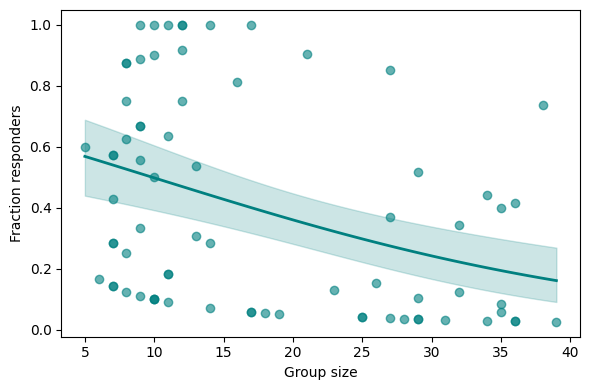

In [69]:

# Scatter
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(
    ResponseVideos['Group_Size'],
    ResponseVideos['Fraction_Responders'],
    'o', alpha=0.6,
    color='Teal'
)

# Prediction grid
x_pred = np.linspace(
    ResponseVideos['Group_Size'].min(),
    ResponseVideos['Group_Size'].max(),
    100
)
pred_df = pd.DataFrame({'Group_Size': x_pred})

# Get predictions + CI
pred = model5.get_prediction(pred_df)
pred_summary = pred.summary_frame()

# Plot mean
ax.plot(
    x_pred,
    pred_summary['mean'],
    linewidth=2,
    color='Teal'
)

# Plot CI
ax.fill_between(
    x_pred,
    pred_summary['mean_ci_lower'],
    pred_summary['mean_ci_upper'],
    alpha=0.2,
    color='Teal'
)

ax.set_xlabel('Group size')
ax.set_ylabel('Fraction responders')

plt.tight_layout()
plt.show()


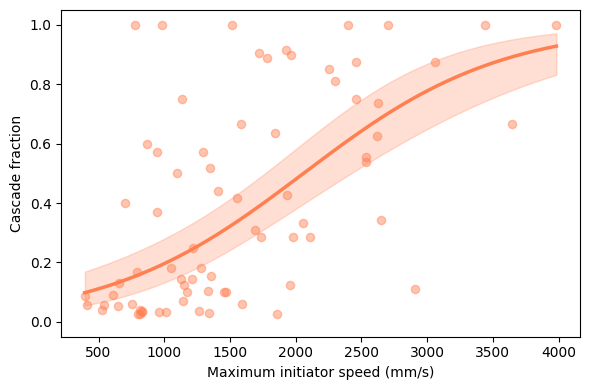

In [70]:
model_speed = smf.glm(
    formula='Nr_Responders + Nr_NonResponders ~ FR_MaxSpeed',
    data=ResponseVideos,
    family=sm.families.Binomial()
).fit(
    cov_type='cluster',
    cov_kwds={'groups': ResponseVideos['Dep_ID']}
)

fig, ax = plt.subplots(figsize=(6,4))

# Scatter: empirical fractions
ax.scatter(
    ResponseVideos['FR_MaxSpeed'],
    ResponseVideos['Fraction_Responders'],
    alpha=0.45,
    s=35,
    color='coral'
)

# Prediction grid
x_pred = np.linspace(
    ResponseVideos['FR_MaxSpeed'].min(),
    ResponseVideos['FR_MaxSpeed'].max(),
    200
)

pred_df = pd.DataFrame({'FR_MaxSpeed': x_pred})

# Predictions + CI
pred = model_speed.get_prediction(pred_df).summary_frame()

# Fitted mean
ax.plot(
    x_pred,
    pred['mean'],
    linewidth=2.5,
    color='coral'
)

# Confidence interval
ax.fill_between(
    x_pred,
    pred['mean_ci_lower'],
    pred['mean_ci_upper'],
    alpha=0.25,
    color='coral'
)

# Labels
ax.set_xlabel('Maximum initiator speed (mm/s)')
ax.set_ylabel('Cascade fraction')

### Labels and formatting

ax.set_xlabel('Maximum initiator speed (mm/s)')
ax.set_ylabel('Cascade fraction')

ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()


### Looking at the videos with 1 FR only; does the group size effect the FR speed?

In [71]:
One_FR = ResponseVideos[ResponseVideos['Nr_FR'] == 1].copy()
# Select only the FR that are part of the videos with 1 FR
FR_fish_1FR = FR_fish[FR_fish['Video_ID'].isin(One_FR['Video_ID'])].copy()

model_1FR = smf.ols(formula='Speed ~ Group_Size * Loom_Speed', data=FR_fish_1FR).fit()
print(model_1FR.summary())

                            OLS Regression Results                            
Dep. Variable:                  Speed   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                    0.8428
Date:                Tue, 03 Feb 2026   Prob (F-statistic):              0.478
Time:                        13:08:00   Log-Likelihood:                -375.59
No. Observations:                  48   AIC:                             759.2
Df Residuals:                      44   BIC:                             766.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept              1778.93

In [72]:
model11 = smf.ols(formula='Fraction_Seeing ~ Group_Size', data=ResponseVideos).fit(cov_type='cluster', cov_kwds={'groups': ResponseVideos['Dep_ID']})
print(model11.summary())

                            OLS Regression Results                            
Dep. Variable:        Fraction_Seeing   R-squared:                       0.183
Model:                            OLS   Adj. R-squared:                  0.172
Method:                 Least Squares   F-statistic:                     38.60
Date:                Tue, 03 Feb 2026   Prob (F-statistic):           6.60e-05
Time:                        13:08:00   Log-Likelihood:                 25.889
No. Observations:                  74   AIC:                            -47.78
Df Residuals:                      72   BIC:                            -43.17
Df Model:                           1                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6378      0.045     14.088      0.0

### Do the closest neighbours of the FR receive enough predicted social input?

In [120]:
# Only look at videos with one responder
One_FR = ResponseVideos[(ResponseVideos['Nr_FR'] == 1) & (ResponseVideos['Nr_FRTC'] == 0)].copy()
Inputs_1FR = model_input.loc[model_input['Video_ID'].isin(One_FR['Video_ID'].tolist())].copy()
Summaries_1FR = Summaries.loc[Summaries['Video_ID'].isin(One_FR['Video_ID'].tolist())].copy()

In [121]:
# Find the FR fish in each video
FR_fish_ids = {}
FR_speeds = {}
for vid in One_FR['Video_ID']:
    fr_fish = Summaries_1FR.loc[
        (Summaries_1FR['Video_ID'] == vid) &
        (Summaries_1FR['Response_Category'] == 'FR'),
        'Fish_ID'
    ].values
    if len(fr_fish) == 1:
        FR_fish_ids[vid] = int(fr_fish[0])
        FR_speeds[vid] = float(Summaries_1FR.loc[
            (Summaries_1FR['Video_ID'] == vid) &
            (Summaries_1FR['Fish_ID'] == fr_fish[0]),
            'Speed'
        ].values[0])
    else:
        FR_fish_ids[vid] = None  # or handle error
        FR_speeds[vid] = None  # or handle error

print(FR_fish_ids)
print(FR_speeds)

{14: 3, 16: 4, 20: 6, 26: 8, 29: 1, 33: 5, 41: 1, 43: 3, 54: 1, 58: 2, 61: 1, 92: 1, 122: 2, 134: 13, 168: 1, 175: 9, 186: 20, 187: 22, 191: 9, 194: 3, 198: 2, 202: 16, 204: 4, 206: 10, 217: 12, 223: 15, 231: 19, 234: 5, 236: 8, 240: 27, 242: 7, 244: 23, 260: 9, 268: 5, 270: 13, 278: 1, 280: 7, 283: 2, 289: 22, 302: 6, 308: 2, 312: 5, 437: 2, 330: 4, 335: 6, 336: 2, 341: 3, 342: 3, 343: 4, 371: 1, 376: 1, 378: 4, 406: 2, 432: 2}
{14: 981.4184206124996, 16: 1591.4816466405944, 20: 778.6458969195186, 26: 1148.5309439286573, 29: 1125.0305054574258, 33: 1454.568296071741, 41: 1136.8199190042296, 43: 2615.834366950716, 54: 1934.1021463232496, 58: 1220.3188126573534, 61: 2106.733097721737, 92: 610.7773246823775, 122: 1049.516089030012, 134: 1513.31053551712, 168: 1140.2187365546447, 175: 1470.8394295101757, 186: 1013.4224299295032, 187: 544.2961945844069, 191: 1854.0759009795056, 194: 941.3648023375682, 198: 798.9077509754374, 202: 1263.5789163988625, 204: 827.3544078064309, 206: 960.6199638

In [141]:
# Identify the K closest neighbors of the FR fish in each video
K = 1
Neighbors_data = []

for vid, fr_id in FR_fish_ids.items():
    if fr_id is None:
        continue  # Skip if no valid FR fish ID

    video_distances = Distances.loc[Distances['Video_ID'] == vid].copy()
    fr_row = video_distances.loc[video_distances['Fish_ID'] == fr_id]

    if fr_row.empty:
        continue  # Skip if FR fish not found in distances

    fr_row = fr_row.iloc[0]
    dist_values = fr_row.drop(labels=['Dep_ID', 'Video_ID', 'Fish_ID', 'Size (in mm)'], errors='ignore')
    dist_values = pd.to_numeric(dist_values, errors='coerce')
    dist_values = dist_values.replace(0, np.nan)

    nearest_neighbors = dist_values.nsmallest(K)
    
    for neighbor_id, distance in nearest_neighbors.items():
        Neighbors_data.append({
            'Video_ID': vid,
            'Group_Size': One_FR.loc[One_FR['Video_ID'] == vid, 'Group_Size'].values[0],
            'FR_Fish_ID': fr_id,
            'FR_Speeds:': FR_speeds[vid],
            'Neighbor_Fish_ID': int(neighbor_id.replace('Distance_to_', '')),
            'Response_Rank': int(Summaries_1FR.loc[
                (Summaries_1FR['Video_ID'] == vid) &
                (Summaries_1FR['Fish_ID'] == int(neighbor_id.replace('Distance_to_', ''))),
                'Response_Rank'
            ].values[0]),
            'Neighbor_Response_Category': Summaries_1FR.loc[
                (Summaries_1FR['Video_ID'] == vid) &
                (Summaries_1FR['Fish_ID'] == int(neighbor_id.replace('Distance_to_', ''))),
                'Response_Category'
            ].values[0],
            'Distance to FR': distance,
            'After_FR': int(Summaries_1FR.loc[
                (Summaries_1FR['Video_ID'] == vid) &
                (Summaries_1FR['Fish_ID'] == int(neighbor_id.replace('Distance_to_', ''))),
                'After_FR'
            ].values[0]) if Summaries_1FR.loc[
                (Summaries_1FR['Video_ID'] == vid) &
                (Summaries_1FR['Fish_ID'] == int(neighbor_id.replace('Distance_to_', ''))),
                'Response_Category'
            ].values[0] not in ['NRL_r', 'NRNL_r'] else np.nan,
            'Density': float(Summaries_1FR.loc[
                (Summaries_1FR['Video_ID'] == vid) &
                (Summaries_1FR['Fish_ID'] == int(neighbor_id.replace('Distance_to_', ''))),
                'Neighbour_Proximity'
            ].values[0])
        })

Neighbors_df = pd.DataFrame(Neighbors_data)

Neighbors_df = Neighbors_df.copy()

Neighbors_df["Response_Category_FirstHop"] = Neighbors_df["Neighbor_Response_Category"]

mask_not_first = Neighbors_df["Response_Rank"] != 2

Neighbors_df.loc[
    mask_not_first & (Neighbors_df["Neighbor_Response_Category"] == "SRL"),
    "Response_Category_FirstHop"
] = "NRL_r"

Neighbors_df.loc[
    mask_not_first & (Neighbors_df["Neighbor_Response_Category"] == "SRNL"),
    "Response_Category_FirstHop"
] = "NRNL_r"

Neighbors_df.head()

,Video_ID,Group_Size,FR_Fish_ID,FR_Speeds:,Neighbor_Fish_ID,Response_Rank,Neighbor_Response_Category,Distance to FR,After_FR,Density,Response_Category_FirstHop
0,14,12,3,981.418421,1,4,SRL,442.828942,12.0,27.350100,NRL_r
1,16,17,4,1591.481647,8,2,NRL_r,411.739083,NaN,38.337072,NRL_r
2,20,12,6,778.645897,8,2,SRL,288.032458,5.0,58.541121,SRL
3,26,8,8,1148.530944,7,2,NRL_r,231.183702,NaN,125.705429,NRL_r
4,29,7,1,1125.030505,2,2,NRNL_r,262.545227,NaN,20.360158,NRNL_r


In [142]:
# Load parameters from model fitting
params = pd.read_csv(path / 'outputs' / 'model_fitting' / 'model_comparisons.csv')
params_bestmodel = params.loc[params['model'] == 'DiTDeS_p1'].copy()

print(params_bestmodel)

        model    core pooling   tau        b0        b1         c  \
12  DiTDeS_p1  DiTDeS     sum  12.0 -0.004832  0.003827  1.799997   

       deviance          AIC        R2  Include_Time  Include_Density  \
12  1313.792039  1321.792039  0.248935             1                1   

    Include_Speed  
12              1  


In [143]:
def add_predicted_input_columns(df_neighbors, *, b0, b1, c, baseline=1e-5):
    df = df_neighbors.copy()

    # --- Unit conversions to match model fitting (R code) ---
    # FR speeds in your df look like mm/s; distances look like mm
    v = np.maximum(df["FR_Speeds:"].to_numpy(dtype=float) / 1000.0, 0.0)  # m/s
    d = np.maximum(df["Distance to FR"].to_numpy(dtype=float) / 1000.0, 1e-9)  # m
    ld = df["Density"].to_numpy(dtype=float)

    # --- Model's D term: v^c * 1/d^2 ---
    D = (v ** c) * (1.0 / (d ** 2))

    # --- Social increment (your "predicted input") ---
    delta_lambda = (b1 * D) * np.exp(b0 * ld)
    delta_lambda = np.maximum(delta_lambda, 0.0)

    # --- (Optional) full hazard and per-frame probability, consistent with fitting code ---
    # In your R: lambda <- (1e-5 + b1*D) * exp(b0*ld)
    lambda_total = (baseline + b1 * np.maximum(D, 0.0)) * np.exp(b0 * ld)
    lambda_total = np.maximum(lambda_total, 0.0)

    # In your R: p <- 1 - exp(-lambda)
    p_frame = 1.0 - np.exp(-lambda_total)

    df["FR_speed_mps"] = v
    df["dist_to_FR_m"] = d
    df["D_term"] = D
    df["delta_lambda"] = delta_lambda
    df["lambda_total"] = lambda_total
    df["p_frame"] = p_frame

    return df

In [149]:
# For all neighbours, calculate their predicted input

b0 = float(params_bestmodel["b0"].iloc[0])
b1 = float(params_bestmodel["b1"].iloc[0])
c  = float(params_bestmodel["c"].iloc[0])

Neighbors_df_pred = add_predicted_input_columns(
    Neighbors_df,
    b0=b0,
    b1=b1,
    c=c,
    baseline=1e-5
)

Neighbors_df_pred["Sees_stimulus"] = Neighbors_df_pred["Response_Category_FirstHop"].isin(["SRL","NRL_r"])
Neighbors_df_pred["Responded_first"] = Neighbors_df_pred["Response_Category_FirstHop"].isin(["SRL","SRNL"])

Neighbors_df_pred.to_csv('../Results/ModelFitting/Predicted_ClosestNeighbors.csv', index=False)


In [150]:
print(pd.crosstab(Neighbors_df_pred["Neighbor_Response_Category"],
                  Neighbors_df_pred["Response_Category_FirstHop"]))
print(Neighbors_df_pred["Response_Category_FirstHop"].value_counts())

Response_Category_FirstHop  NRL_r  NRNL_r  SRL  SRNL
Neighbor_Response_Category                          
NRL_r                          21       0    0     0
NRNL_r                          0      11    0     0
SRL                             8       0    8     0
SRNL                            0       3    0     3
Response_Category_FirstHop
NRL_r     29
NRNL_r    14
SRL        8
SRNL       3
Name: count, dtype: int64


## Q1) Do the 4 groups differ in predicted social input (Δλ)?


                             n    median       q25       q75
Response_Category_FirstHop                                  
SRL                          8  0.034992  0.020542  0.229936
NRL_r                       29  0.037013  0.010456  0.066487
SRNL                         3  0.049872  0.027089  0.088464
NRNL_r                      14  0.034667  0.013254  0.054186


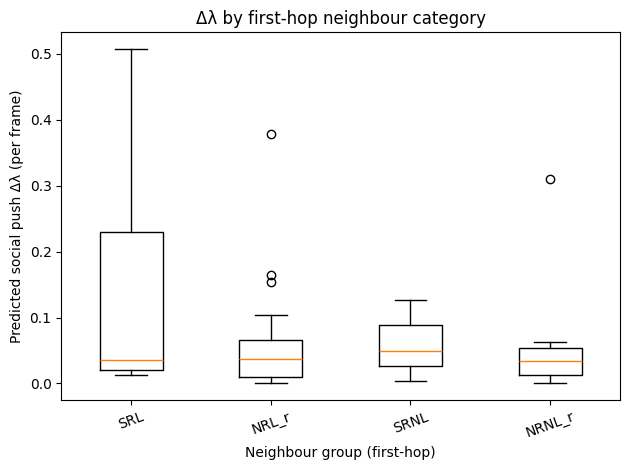

In [153]:
cats = ["SRL", "NRL_r", "SRNL", "NRNL_r"]

# Summary table
summ = (Neighbors_df_pred.groupby("Response_Category_FirstHop")["delta_lambda"]
        .agg(n="count", median="median",
             q25=lambda x: np.quantile(x, 0.25),
             q75=lambda x: np.quantile(x, 0.75))
        .reindex(cats))
print(summ)

# Boxplot
data = [Neighbors_df_pred.loc[Neighbors_df_pred["Response_Category_FirstHop"]==c, "delta_lambda"].dropna().values
        for c in cats]

plt.figure()
plt.boxplot(data, tick_labels=cats)
plt.xlabel("Neighbour group (first-hop)")
plt.ylabel("Predicted social push Δλ (per frame)")
plt.title("Δλ by first-hop neighbour category")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [155]:
from scipy.stats import kruskal

groups = [Neighbors_df_pred.loc[Neighbors_df_pred["Response_Category_FirstHop"]==c, "delta_lambda"].dropna().values
          for c in cats]
stat, p = kruskal(*groups)
print("Kruskal–Wallis:", stat, p)


Kruskal–Wallis: 1.134746479574062 0.7686934509992687


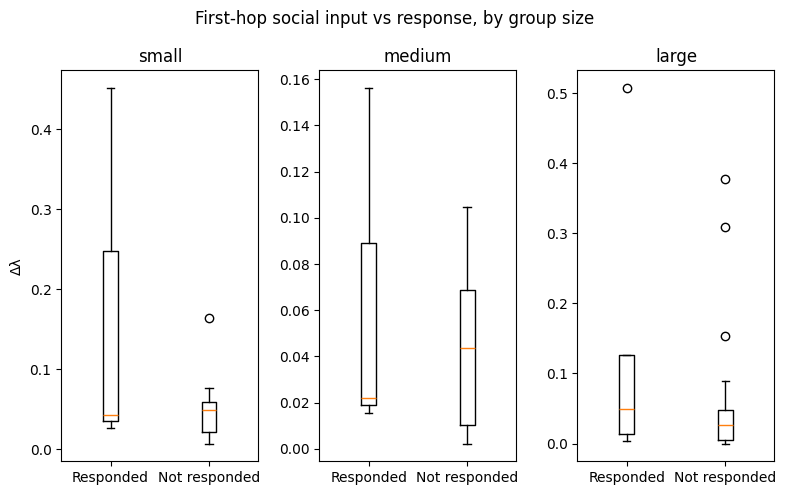

In [167]:
bins   = [0, 10, 15, 100]
labels = ["small", "medium", "large"]
Neighbors_df_pred["GS_bin"] = pd.cut(Neighbors_df_pred["Group_Size"], bins=bins, labels=labels)

plt.figure(figsize=(8,5))
for i, lab in enumerate(labels, start=1):
    subset = Neighbors_df_pred[Neighbors_df_pred["GS_bin"] == lab]
    if subset.empty:
        continue
    data = [
        subset.loc[subset["responded_first"]==1, "delta_lambda"].dropna(),
        subset.loc[subset["responded_first"]==0, "delta_lambda"].dropna()
    ]
    plt.subplot(1,3,i)
    plt.boxplot(data, tick_labels=["Responded","Not responded"])
    plt.title(lab)
    plt.ylabel("Δλ" if i==1 else "")
plt.suptitle("First-hop social input vs response, by group size")
plt.tight_layout()
plt.show()

In [168]:
dfm = Neighbors_df_pred.dropna(subset=["delta_lambda","Group_Size","responded_first"]).copy()

model = smf.glm(
    formula="responded_first ~ delta_lambda * Group_Size",
    data=dfm,
    family=sm.families.Binomial()
).fit(cov_type="cluster", cov_kwds={"groups": dfm["Video_ID"]})

print(model.summary())

                                  Generalized Linear Model Regression Results                                  
Dep. Variable:     ['responded_first[False]', 'responded_first[True]']   No. Observations:                   54
Model:                                                             GLM   Df Residuals:                       50
Model Family:                                                 Binomial   Df Model:                            3
Link Function:                                                   Logit   Scale:                          1.0000
Method:                                                           IRLS   Log-Likelihood:                -24.940
Date:                                                 Tue, 03 Feb 2026   Deviance:                       49.879
Time:                                                         15:22:39   Pearson chi2:                     54.4
No. Iterations:                                                      5   Pseudo R-squ. (CS):            

## Q2) Pure social pathway: Among fish that did NOT see the stimulus, do first responders have higher Δλ?

n SRNL: 3 n NRNL_r: 14
median SRNL: 0.04987234040382807 median NRNL_r: 0.03466684228141423


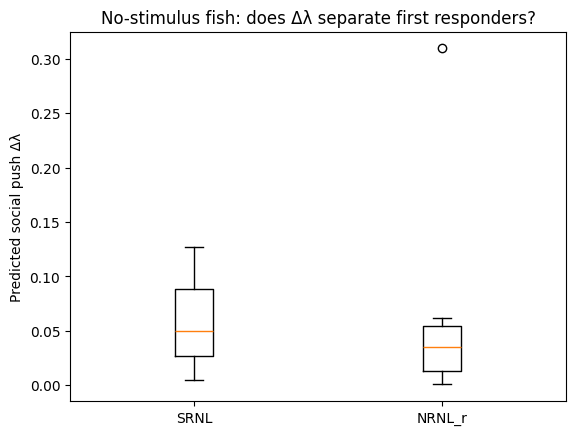

Mann–Whitney U: 26.0 0.5911764705882353


In [156]:
from scipy.stats import mannwhitneyu

no_stim = Neighbors_df_pred[Neighbors_df_pred["sees_stimulus"] == False]

srnl  = no_stim.loc[no_stim["Response_Category_FirstHop"]=="SRNL", "delta_lambda"].dropna()
nrnl  = no_stim.loc[no_stim["Response_Category_FirstHop"]=="NRNL_r", "delta_lambda"].dropna()

print("n SRNL:", len(srnl), "n NRNL_r:", len(nrnl))
print("median SRNL:", np.median(srnl), "median NRNL_r:", np.median(nrnl))

# Plot
plt.figure()
plt.boxplot([srnl.values, nrnl.values], tick_labels=["SRNL", "NRNL_r"])
plt.ylabel("Predicted social push Δλ")
plt.title("No-stimulus fish: does Δλ separate first responders?")
plt.show()

# Test (two-sided)
stat, p = mannwhitneyu(srnl, nrnl, alternative="two-sided")
print("Mann–Whitney U:", stat, p)


## Q3) Does stimulus change how social input matters?

In [159]:
import statsmodels.formula.api as smf

dfm = Neighbors_df_pred.dropna(subset=["delta_lambda", "sees_stimulus", "responded_first"]).copy()
dfm["responded_first"] = dfm["responded_first"].astype(int)

model = smf.glm(
    formula="responded_first ~ delta_lambda * sees_stimulus",
    data=dfm,
    family=sm.families.Binomial()
).fit(cov_type="cluster", cov_kwds={"groups": dfm["Video_ID"]})

print(model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:        responded_first   No. Observations:                   54
Model:                            GLM   Df Residuals:                       50
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -25.407
Date:                Tue, 03 Feb 2026   Deviance:                       50.815
Time:                        15:04:05   Pearson chi2:                     54.6
No. Iterations:                     4   Pseudo R-squ. (CS):            0.06758
Covariance Type:              cluster                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

## Q4) Does group size explain differences in first-hop responding?

In [162]:
dfm = Neighbors_df_pred.dropna(subset=["delta_lambda","Group_Size","sees_stimulus","responded_first"]).copy()
dfm["responded_first"] = dfm["responded_first"].astype(int)

model_gs = smf.glm(
    formula="responded_first ~ delta_lambda * sees_stimulus + Group_Size",
    data=dfm,
    family=sm.families.Binomial()
).fit(cov_type="cluster", cov_kwds={"groups": dfm["Video_ID"]})

print(model_gs.summary())

# Optional: allow Δλ to depend on Group_Size
model_gs_int = smf.glm(
    formula="responded_first ~ sees_stimulus + delta_lambda * Group_Size",
    data=dfm,
    family=sm.families.Binomial()
).fit(cov_type="cluster", cov_kwds={"groups": dfm["Video_ID"]})

print(model_gs_int.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:        responded_first   No. Observations:                   54
Model:                            GLM   Df Residuals:                       49
Model Family:                Binomial   Df Model:                            4
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -25.402
Date:                Tue, 03 Feb 2026   Deviance:                       50.804
Time:                        15:04:38   Pearson chi2:                     54.8
No. Iterations:                     4   Pseudo R-squ. (CS):            0.06777
Covariance Type:              cluster                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

## Q5) “Enough for anyone?” (video-level: does any fish respond after FR)

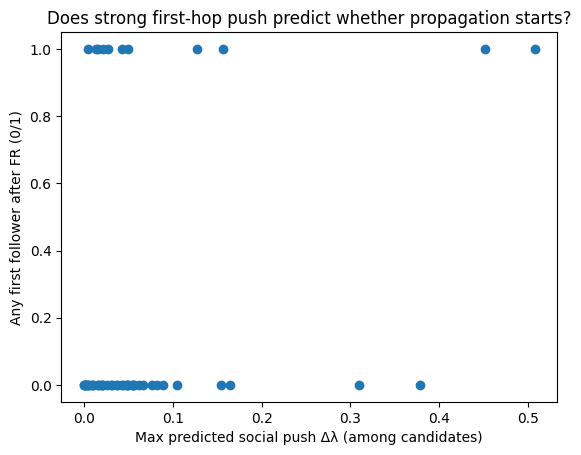

                  Generalized Linear Model Regression Results                  
Dep. Variable:     any_first_responder   No. Observations:                   54
Model:                             GLM   Df Residuals:                       51
Model Family:                 Binomial   Df Model:                            2
Link Function:                   Logit   Scale:                          1.0000
Method:                           IRLS   Log-Likelihood:                -25.524
Date:                 Tue, 03 Feb 2026   Deviance:                       51.048
Time:                         15:05:07   Pearson chi2:                     54.7
No. Iterations:                      4   Pseudo R-squ. (CS):            0.06354
Covariance Type:             nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -1.7253   

In [163]:
vid = (Neighbors_df_pred.groupby("Video_ID")
       .agg(
           Group_Size=("Group_Size","first"),
           max_delta_lambda=("delta_lambda","max"),
           any_first_responder=("responded_first","max")  # True if any candidate is first responder
       )
       .reset_index())

vid["any_first_responder"] = vid["any_first_responder"].astype(int)

plt.figure()
plt.scatter(vid["max_delta_lambda"], vid["any_first_responder"])
plt.xlabel("Max predicted social push Δλ (among candidates)")
plt.ylabel("Any first follower after FR (0/1)")
plt.title("Does strong first-hop push predict whether propagation starts?")
plt.show()

model_vid = smf.glm(
    formula="any_first_responder ~ max_delta_lambda + Group_Size",
    data=vid,
    family=sm.families.Binomial()
).fit()

print(model_vid.summary())


## Speed decay parameter

Estimates the exponential speed decay rate λ from SRNL fish speed data (v(t) = i + a·exp(-λt)). This λ value feeds directly into the simulations as `speed_decay` in `scripts/simulations/00_config.R`.

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# Model: v(t) = i + a * exp(-lambda * t)
def exp_decay_i(t, i, a, lam):
    return i + a * np.exp(-lam * t)

def fit_lambda_binned_median(df, time_col="After_FR", speed_col="Speed", bin_width=5, min_n_per_bin=3):
    d = df.copy()
    d["t"] = pd.to_numeric(d[time_col], errors="coerce")
    d["v"] = pd.to_numeric(d[speed_col], errors="coerce") / 1000.0  # mm/s -> m/s
    d = d[np.isfinite(d["t"]) & np.isfinite(d["v"])].copy()

    d["bin"] = (d["t"] // bin_width).astype(int)
    b = (
        d.groupby("bin", as_index=False)
         .agg(t_med=("t", "median"), v_med=("v", "median"), n=("bin", "size"))
    )
    b = b[b["n"] >= min_n_per_bin].copy()

    if len(b) < 4:
        raise RuntimeError("Not enough binned points to fit exponential decay.")

    t = b["t_med"].to_numpy()
    v = b["v_med"].to_numpy()

    i0 = max(0.0, float(np.min(v)))
    a0 = max(1e-6, float(np.max(v) - np.min(v)))
    lam0 = 0.05

    popt, pcov = curve_fit(
        exp_decay_i,
        t,
        v,
        p0=(i0, a0, lam0),
        bounds=([0.0, 1e-6, 1e-6], [np.inf, np.inf, np.inf]),
        maxfev=20000,
    )

    i_hat, a_hat, lambda_hat = popt
    return {"i": i_hat, "a": a_hat, "lambda": lambda_hat, "pcov": pcov, "binned": b}

def bootstrap_lambda_rowwise(
    df,
    B=1000,
    seed=42,
    time_col="After_FR",
    speed_col="Speed",
    bin_width=5,
    min_n_per_bin=3,
):
    rng = np.random.default_rng(seed)
    n = len(df)
    lambdas = []

    for _ in range(B):
        idx = rng.integers(0, n, n)  # row bootstrap
        boot = df.iloc[idx].copy()

        try:
            fit = fit_lambda_binned_median(
                boot,
                time_col=time_col,
                speed_col=speed_col,
                bin_width=bin_width,
                min_n_per_bin=min_n_per_bin,
            )
            lam = fit["lambda"]
            if np.isfinite(lam):
                lambdas.append(lam)
        except Exception:
            pass

    lambdas = np.array(lambdas, dtype=float)
    if len(lambdas) == 0:
        raise RuntimeError("All bootstrap fits failed.")

    lo, med, hi = np.quantile(lambdas, [0.025, 0.5, 0.975])
    return {
        "lambda_hat_median": med,
        "lambda_ci95": (lo, hi),
        "lambda_samples": lambdas,
        "n_success": len(lambdas),
        "B": B,
    }

# ---- Usage on your real data ----
Summaries_SRNL = Summaries[Summaries["Response_Category"] == "SRNL"].copy()
fit_main = fit_lambda_binned_median(Summaries_SRNL, time_col="After_FR", speed_col="Speed", bin_width=5)
boot = bootstrap_lambda_rowwise(Summaries_SRNL, B=1000, seed=1, time_col="After_FR", speed_col="Speed", bin_width=5)

print(f"Main fit lambda (bin=5): {fit_main['lambda']:.6f}")
print(f"Bootstrap median lambda: {boot['lambda_hat_median']:.6f}")
print(f"95% CI: [{boot['lambda_ci95'][0]:.6f}, {boot['lambda_ci95'][1]:.6f}]")
print(f"Successful fits: {boot['n_success']}/{boot['B']}")
